In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import ast

In [2]:
h1 = 1
m = 0.5
def coupling(matrix_1, matrix_2):
    s11_1, s12_1 = matrix_1[0, 0], matrix_1[0, 1]
    s21_1, s22_1 = matrix_1[1, 0], matrix_1[1, 1]
    s11_2, s12_2 = matrix_2[0, 0], matrix_2[0, 1]
    s21_2, s22_2 = matrix_2[1, 0], matrix_2[1, 1]
    
    denom = 1 - s11_2 * s22_1
    s11 = s11_1 + s12_1 * s21_1 * s11_2 / denom
    s12 = s12_1 * s12_2 / denom
    s21 = s21_2 * s21_1 / denom
    s22 = s22_2 + s21_2 * s12_2 * s22_1 / denom
    
    return np.array([[s11, s12], [s21, s22]], dtype=np.complex128)

def multiple_coupling(matrix_collect):
    result = matrix_collect[0]
    for matrix in matrix_collect[1:]:
        result = coupling(result, matrix)
    return result

def coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a):
    constant_1 = 2 * m * (y1 + 1j * y2) / (h1**2)
    constant_2 = 2 * m * (y1 - 1j * y2) / (h1**2)
    
    di = np.array([constant_1 if i % 2 == 0 or i >= 2 * N and i < 2 * N + n3 else constant_2 
                   for i in range(2 * N + n3 + n4)], dtype=complex)
    
    x_0 = 0
    x_1 = a * (2 * N + n3 + n4) - a + x_0
    location = np.linspace(x_0, x_1, 2 * N + n3 + n4)
 #   print(location)
    k = np.sqrt(E * 2 * m) / h1
    exp_2jk = np.exp(2j * k * location)
    exp_minus_2jk = np.exp(-2j * k * location)
    
    matrix_collect = np.zeros((2 * N + n3 + n4, 2, 2), dtype=complex)
    for i in range(2 * N + n3 + n4):
        s11 = di[i] * exp_2jk[i]
        s12 = 2j * k
        s21 = 2j * k
        s22 = di[i] * exp_minus_2jk[i]
        
        matrix_collect[i] = np.array([[s11, s12], [s21, s22]]) / (-di[i] + 2j * k)
  #  print(matrix_collect)
    return multiple_coupling(matrix_collect)

def Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a):
    matrix = coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a)
    return float(np.abs(matrix[1, 0])**2)

def Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a):
    matrix = coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a)
    return float(np.abs(matrix[0, 0])**2)

In [ ]:
#测试
# 参数设置
N = 100
n3 = 0
n4 = 0
y1 = 2
y2 = -2
dianshu=10000
E=5
a_set__1 = np.linspace(0,10,dianshu)            
#a = 0.5                    #######np.linspace(0, 20, 10000)

# 计算数据
T_set__1 = [Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for a in a_set__1]
R_set__1 = [Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for a in a_set__1]
Sum_values__1 = [T + R   for T, R in zip(T_set__1, R_set__1)]


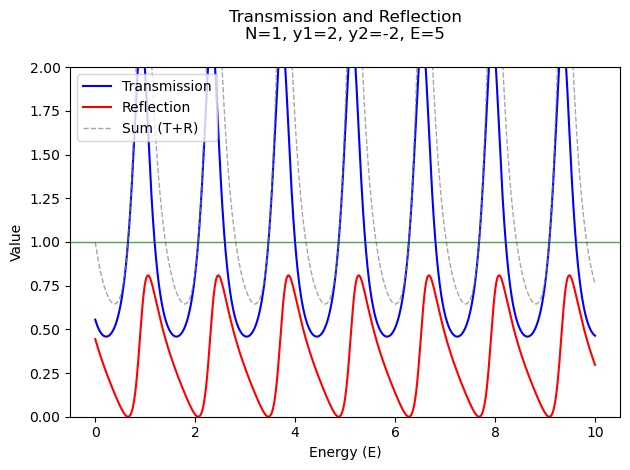

In [20]:
plt.plot(a_set__1, T_set__1,color='blue',label='Transmission')  
plt.plot(a_set__1, R_set__1,color='red',label='Reflection')  
plt.plot(a_set__1, Sum_values__1, 
         color='gray', linestyle='--', 
         linewidth=1, alpha=0.7,
         label='Sum (T+R)')
plt.title(f'Transmission and Reflection\nN={N}, y1={y1}, y2={y2}, E={E}', pad=20)
plt.xlabel('Energy (E)')
plt.ylabel('Value')

plt.axhline(y=1, color='green', linestyle='-', linewidth=1, alpha=0.7)
plt.ylim(0, 2)
#plt.xlim(0, 100)
plt.legend()
plt.tight_layout()
#构建保存路径
save_folder = fr"C:\Users\taoji\Desktop\草稿纸"
image_name = f"_N{N}_n3{n3}_n4{n4}_y1{y1}_y2{y2}_a{E}_plot.png"
save_path = os.path.join(save_folder, image_name)

#保存图像
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

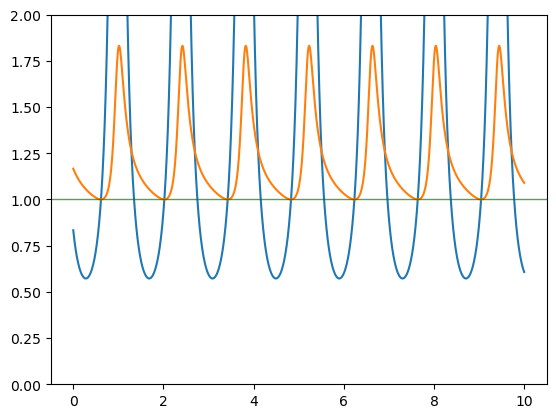

In [19]:
plt.plot(a_set__1,np.array(T_set__1)+1)
plt.plot(a_set__1,np.array(R_set__1)+1)

plt.axhline(y=1, color='green', linestyle='-', linewidth=1, alpha=0.7)
plt.ylim(0, 2)
#plt.xlim(0, 100)
plt.show()

In [18]:
#测试
# 参数设置
N = 1
n3 = 0
n4 = 0
y1 = 1
y2 = -4
dianshu=10000
E=5
a_set__1 = np.linspace(0,10,dianshu)            
#a = 0.5                    #######np.linspace(0, 20, 10000)

# 计算数据
T_set__1 = [Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a)-1 for a in a_set__1]
R_set__1 = [Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for a in a_set__1]
Sum_values__1 = [T + R   for T, R in zip(T_set__1, R_set__1)]


In [4]:
#PT与散射矩阵
N = 31
n3 = 0
n4 = 0
y1 = 2
y2 = 0
E = 3
a = 0.5 
matrix=coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a)
r=matrix[0][0]
t=matrix[1][0]
r_1=matrix[1][1]
t_1=matrix[0][1]
#print(np.conj(r),r)
denom_1=np.conj(-r_1*r+t*t_1)
copy_r=(np.conj(-r)/denom_1)
copy_t=(np.conj(t_1)/denom_1)
copy_r_1=(np.conj(-r_1)/denom_1)
copy_t_1=(np.conj(t)/denom_1)

In [ ]:
# 参数设置
N = 100
n3 = 0
n4 = 0
y1 = 2  
y2 = 2
dianshu=400000
E_set = np.linspace(0,400,dianshu)            
a = 0.5                    #######np.linspace(0, 20, 10000)

# 计算数据
T_set = [Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for E in E_set]
R_set = [Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for E in E_set]
Sum_values = [T + R for T, R in zip(T_set, R_set)]
# 创建DataFrame保存数据
data = {
    'E_set': E_set,
    'T_set': T_set,
    'R_set': R_set,
    'Sum_values': Sum_values
}
df = pd.DataFrame(data)

# 创建保存路径
save_dir = fr"C:\Users\taoji\Desktop\结果\2025.5.3后_Python运行结果\N_{N},y1_{y1},y2_{y2}"
os.makedirs(save_dir, exist_ok=True)

# 按参数命名文件
filename = f"N{N}_n3{n3}_n4{n4}_y1{y1}_y2{y2}_a{a}_E_change.xlsx"
save_path = os.path.join(save_dir, filename)

# 保存到Excel
df.to_excel(save_path, index=False)
print(f"数据已保存至: {save_path}")

C:\Users\taoji\AppData\Local\Temp\ipykernel_14008\1870253545.py:10: RuntimeWarning: invalid value encountered in scalar divide
  s11 = s11_1 + s12_1 * s21_1 * s11_2 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_14008\1870253545.py:11: RuntimeWarning: invalid value encountered in scalar divide
  s12 = s12_1 * s12_2 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_14008\1870253545.py:12: RuntimeWarning: invalid value encountered in scalar divide
  s21 = s21_2 * s21_1 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_14008\1870253545.py:13: RuntimeWarning: invalid value encountered in scalar divide
  s22 = s22_2 + s21_2 * s12_2 * s22_1 / denom


数据已保存至: C:\Users\taoji\Desktop\结果\2025.5.3后_Python运行结果\N_100,y1_2,y2_2\N100_n30_n40_y12_y22_a0.5_E_change.xlsx


In [84]:
# 读取 Excel 文件  透射
N = 100
n3 = 0
n4 = 0
y1 = 2
y2 = 2
a = 0.5  
file_name = f"N{N}_n3{n3}_n4{n4}_y1{y1}_y2{y2}_a{a}_E_change.xlsx"
save_dir = fr"C:\Users\taoji\Desktop\结果\2025.5.3后_Python运行结果\N_{N},y1_{y1},y2_{y2}"
save_path = os. path.join(save_dir, file_name)
loaded_df = pd.read_excel(save_path)

# 将字符串形式的列表转换为实际的列表
def safe_literal_eval(x):
    if isinstance(x, str):  # 如果是字符串才尝试解析
        try:
            return ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return x
    else:  # 已经是数字或列表就直接返回
        return x

E_set = loaded_df["E_set"].apply(safe_literal_eval)
T_set = loaded_df["T_set"].apply(safe_literal_eval)
R_set = loaded_df["R_set"].apply(safe_literal_eval)
Sum_values_set = loaded_df["Sum_values"].apply(safe_literal_eval)



In [52]:
# 读取 Excel 文件  能带数据
N = 100
y1 = 2
y2 = 2
a = 0.5
E_min = 0
E_max = 400
k=10

file_name = f"能带数据N{N}_y1{y1}_y2{y2}_a{a}_Emin{E_min}_Emax{E_max}_k{k}.xlsx"
save_path = os. path.join(fr"C:\Users\taoji\Desktop\结果\2025.5.3后_Python运行结果\N_{N},y1_{y1},y2_{y2}", file_name)
loaded_df = pd.read_excel(save_path)

gongzhen =loaded_df["E"]
#print("从 Excel 加载的字典（列表格式）:", energy_levels)
#type(gongzhen[2])

file_name = f"能带数据N{N}_y1{y1}_y2{y2}_a{a}_Emin{E_min}_Emax{E_max}_k{k}_最大值处.xlsx"
save_path = os. path.join(fr"C:\Users\taoji\Desktop\结果\2025.5.3后_Python运行结果\N_{N},y1_{y1},y2_{y2}", file_name)
loaded_df_1 = pd.read_excel(save_path)

zuidashi =loaded_df_1["E"]


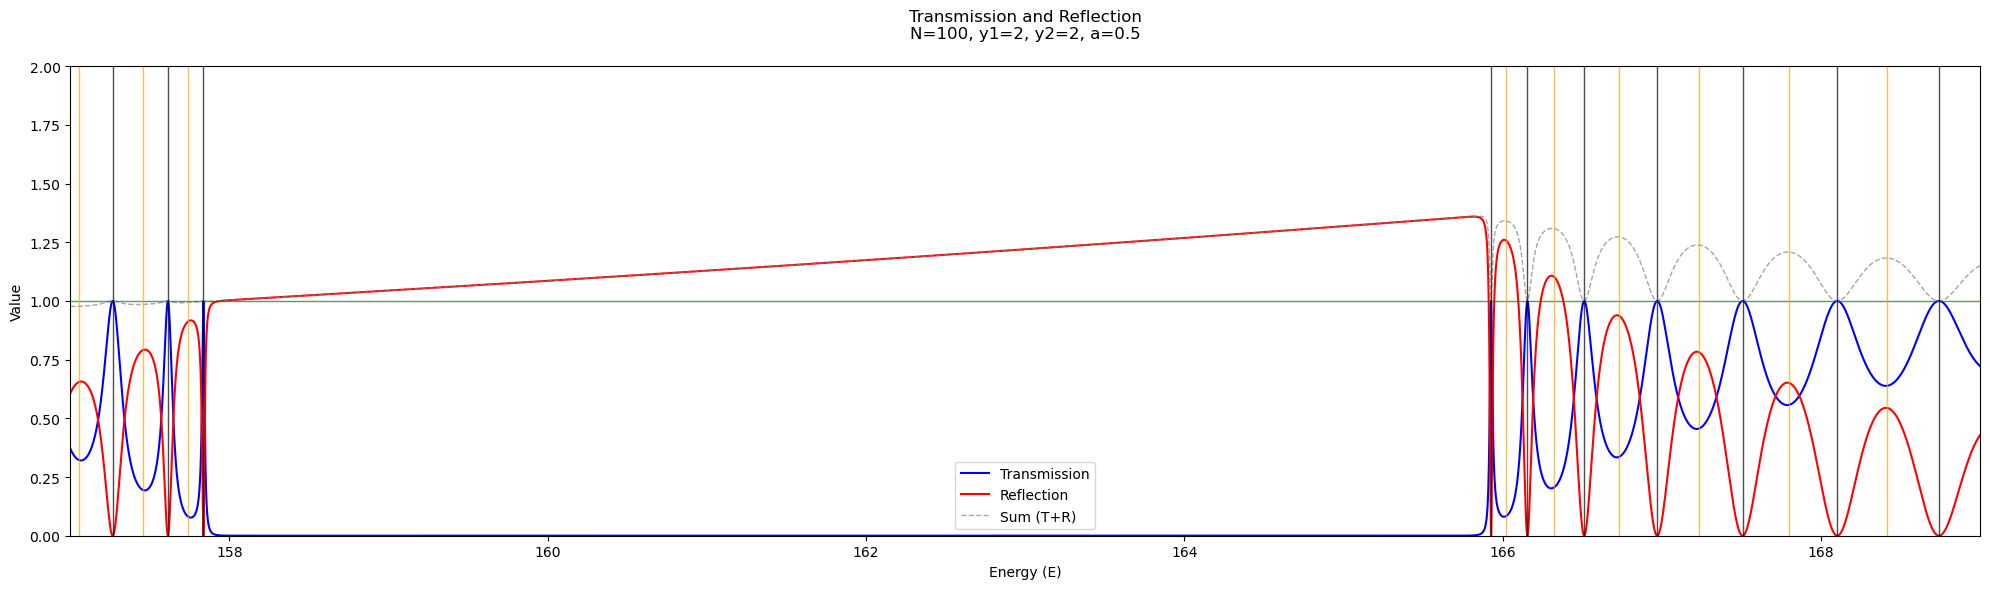

In [ ]:
E_kaishi=157
E_jieshu=169
pushu_qi=int(400000*E_kaishi/400)
pushu_jie=int(400000*E_jieshu/400)
E_set_1=E_set[pushu_qi:pushu_jie]
T_set_1=T_set[pushu_qi:pushu_jie]
R_set_1=R_set[pushu_qi:pushu_jie]
Sum_values_set_1=Sum_values_set[pushu_qi:pushu_jie]

gongzhen_3=[num for num in gongzhen if E_kaishi <= num <= E_jieshu]
zuidashi_3=[num for num in zuidashi if E_kaishi <= num <= E_jieshu]

shidong=1
plt.figure(figsize=(20, 6))
plt.plot(E_set_1, T_set_1,color='blue',label='Transmission')  
plt.plot(E_set_1, R_set_1,color='red',label='Reflection')  
plt.plot(E_set_1, Sum_values_set_1, 
         color='gray', linestyle='--', 
         linewidth=1, alpha=0.7,
         label='Sum (T+R)')
plt.title(f'Transmission and Reflection\nN={N}, y1={y1}, y2={y2}, a={a}', pad=20)
plt.xlabel('Energy (E)')
plt.ylabel('Value')

plt.ylim(0, 2)
plt.xlim(E_kaishi, E_jieshu)
plt.axhline(y=1, color='green', linestyle='-', linewidth=1, alpha=0.7)
for gongzhenzhi in gongzhen_3:
    plt.axvline(x=gongzhenzhi, color='black', linestyle='-', linewidth=1, alpha=0.7)
for zuidashi_1 in zuidashi_3:
    plt.axvline(x=zuidashi_1, color='orange', linestyle='-', linewidth=1, alpha=0.7)
#ax.axvline(x=157.913670417430, color='green', linestyle='-', linewidth=1, alpha=0.7)
#ax.axvline(x=165.848348494293, color='green', linestyle='-', linewidth=1, alpha=0.7)

plt.legend()
plt.tight_layout()

if shidong==1:
    #构建保存路径
    save_folder = fr"C:\Users\taoji\Desktop\研究生工作\N_{N},y1_{y1},y2_{y2}"
    image_name = f"{E_kaishi,E_jieshu}_N{N}_n3{n3}_n4{n4}_y1{y1}_y2{y2}_a{a}_plot.png"
    save_path = os.path.join(save_folder, image_name)

    #保存图像
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# 参数设置
N = 100
n3 = 0
n4 = 0
y1 = 2
y2 = -2
E_set = np.linspace(0.0000001,400,40000)
a = 0.5                    #######np.linspace(0, 20, 10000)

# 计算数据
T_set = [Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for E in E_set]
R_set = [Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for E in E_set]
Sum_values = [T + R for T, R in zip(T_set, R_set)]
# 创建DataFrame保存数据
data = {
    'E_set': E_set,
    'T_set': T_set,
    'R_set': R_set,
    'Sum_values': Sum_values
}
df = pd.DataFrame(data)

# 创建保存路径
save_dir = r"C:\Users\taoji\Desktop\结果\2025.5.3后_Python运行结果"
os.makedirs(save_dir, exist_ok=True)

# 按参数命名文件
filename = f"N{N}_n3{n3}_n4{n4}_y1{y1}_y2{y2}_a{a}_E_change.xlsx"
save_path = os.path.join(save_dir, filename)

# 保存到Excel
df.to_excel(save_path, index=False)
print(f"数据已保存至: {save_path}")